# Analysis of impact of wind conditions using boostrapping methods

In [1]:
# imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from plot_methods import get_parity_data

In [2]:
# import all data
op = 'all'
[data, desc] = get_parity_data(op, wind_analysis=True)

In [3]:
data.head()

,release_rate,release_sigma,operator_report,operator_sigma_lower,operator_sigma_upper,windspeed_bin,windspeed_variation_coeff_bin,winddir_variation_coeff_bin
16,16.95,0,6.25,1.46,1.46,[2.0-4.0),[0-25%),[0-10%)
18,115.00,0,50.27,12.01,12.01,[2.0-4.0),[25-50%),[0-10%)
20,38.52,0,25.81,4.14,4.14,[4.0-6.0),[0-25%),[0-10%)
22,103.20,0,52.73,14.81,14.82,[2.0-4.0),[0-25%),[0-10%)
27,43.49,0,10.27,4.75,4.74,[2.0-4.0),[25-50%),[0-10%)


In [4]:
# initialize dataframes
all_windspeed_avg_bins = data.windspeed_bin.unique()
windspeed_avg_slopes = pd.DataFrame(columns=all_windspeed_avg_bins)

In [5]:
windspeed_avg_slopes

,[2.0-4.0),[4.0-6.0),[0.0-2.0)


In [6]:
# initialize dataframes
all_windspeed_avg_bins = data.windspeed_bin.unique()
windspeed_avg_slopes = pd.DataFrame(columns=all_windspeed_avg_bins)
windspeed_avg_intercepts = pd.DataFrame(columns=all_windspeed_avg_bins)
windspeed_avg_num_datapoints = pd.DataFrame(columns=all_windspeed_avg_bins)

all_windspeed_cov_bins = data.windspeed_variation_coeff_bin.unique()
windspeed_cov_slopes = pd.DataFrame(columns=all_windspeed_cov_bins)
windspeed_cov_intercepts = pd.DataFrame(columns=all_windspeed_cov_bins)
windspeed_cov_num_datapoints = pd.DataFrame(columns=all_windspeed_cov_bins)

all_winddir_cov_bins = data.winddir_variation_coeff_bin.unique()
winddir_cov_slopes = pd.DataFrame(columns=all_winddir_cov_bins)
winddir_cov_intercepts = pd.DataFrame(columns=all_winddir_cov_bins)
winddir_cov_num_datapoints = pd.DataFrame(columns=all_winddir_cov_bins)

# define number of bootstrapping realizations to create
N = 1000

for i in range(N):
    # create bootstrap sample by resampling with replacement (same size dataset)
    resampled_df = data.sample(n=len(data), replace=True)

    ### WINDSPEED AVG
    # define the unique windspeed bins and iterate through them to calculate slope (m) and intercept (b)
    windspeed_bins = resampled_df.windspeed_bin.unique()
    for bin in windspeed_bins:
        # get bin data 
        bin_data = resampled_df[resampled_df.windspeed_bin == bin]
        # store number of points
        windspeed_avg_num_datapoints.loc[i, bin] = len(bin_data)
        if len(bin_data) >= 5:
            # calculate slope and intercept
            m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
            # store data 
            windspeed_avg_slopes.loc[i, bin] = m
            windspeed_avg_intercepts.loc[i, bin] = b
        else:
            windspeed_avg_slopes.loc[i, bin] = np.nan
            windspeed_avg_intercepts.loc[i, bin] = np.nan

    ### WINDSPEED COV
    windspeed_cov_bins = resampled_df.windspeed_variation_coeff_bin.unique()
    for bin in windspeed_cov_bins:
        # get bin data 
        bin_data = resampled_df[resampled_df.windspeed_variation_coeff_bin == bin]
        # store number of points
        windspeed_cov_num_datapoints.loc[i, bin] = len(bin_data)
        # calculate slope and intercept and store data
        if len(bin_data) >= 5:
            m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
            windspeed_cov_slopes.loc[i, bin] = m
            windspeed_cov_intercepts.loc[i, bin] = b
        else:
            windspeed_cov_slopes.loc[i, bin] = np.nan
            windspeed_cov_intercepts.loc[i, bin] = np.nan

    ### WINDDIR COV
    winddir_cov_bins = resampled_df.winddir_variation_coeff_bin.unique()
    for bin in winddir_cov_bins:
        # get bin data 
        bin_data = resampled_df[resampled_df.winddir_variation_coeff_bin == bin]
        # store number of points
        winddir_cov_num_datapoints.loc[i, bin] = len(bin_data)
        if len(bin_data) >= 5:
            # calculate slope and intercept
            m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
            # store data 
            winddir_cov_slopes.loc[i, bin] = m
            winddir_cov_intercepts.loc[i, bin] = b
        else:
            winddir_cov_slopes.loc[i, bin] = np.nan 
            winddir_cov_intercepts.loc[i, bin] = np.nan

/var/folders/x6/v_n74jv12c5f1qrps_2t8smw0000gn/T/ipykernel_32172/1671472098.py:51: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
/var/folders/x6/v_n74jv12c5f1qrps_2t8smw0000gn/T/ipykernel_32172/1671472098.py:51: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
/var/folders/x6/v_n74jv12c5f1qrps_2t8smw0000gn/T/ipykernel_32172/1671472098.py:51: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
/var/folders/x6/v_n74jv12c5f1qrps_2t8smw0000gn/T/ipykernel_32172/1671472098.py:51: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(bin_data.release_rate, bin_data.operator_report, deg=1)
/var/folders/x6/v_n74jv12c5f1qrps_2t8smw0000gn/T/ipykernel_32172/1671472098.py:51: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(bin_data.release_rate, bin

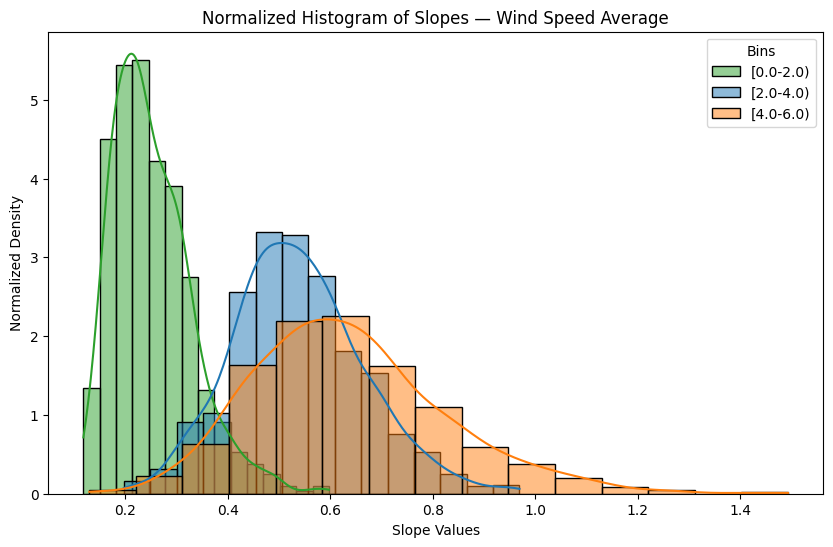

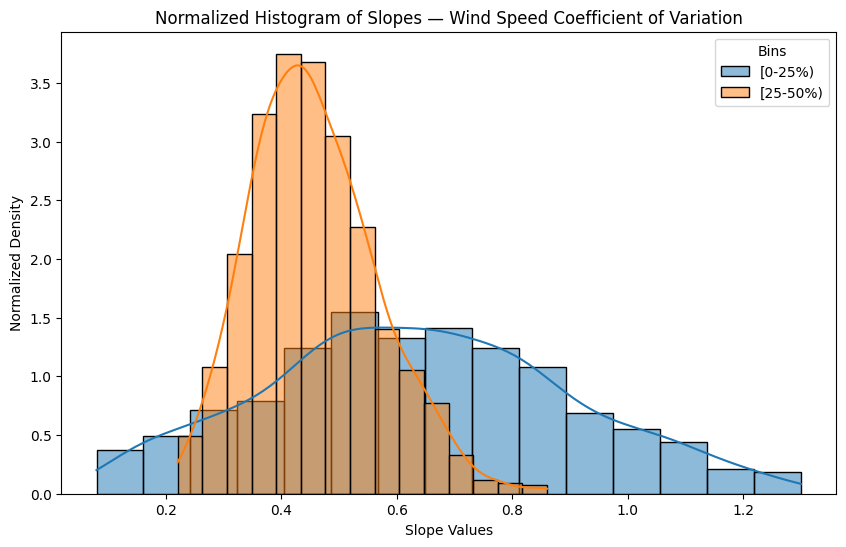

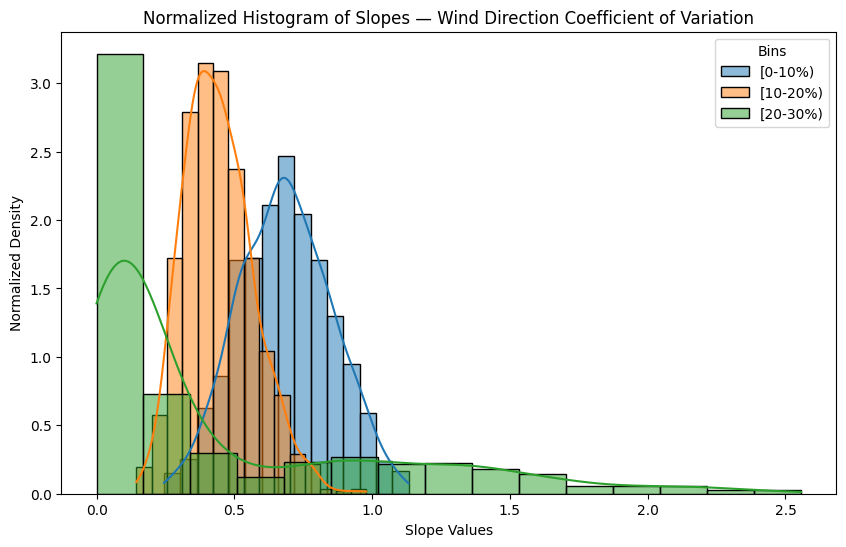

In [7]:
def plot_slope_histograms(slope_df, title):
    plt.figure(figsize=(10, 6))
    for bin in sorted(slope_df.columns):
        slopes = slope_df[bin].dropna()
        sns.histplot(
            slopes,
            label=bin,
            kde=True,
            bins=15,
            stat="density",
            color=sns.color_palette("tab10")[list(slope_df.columns).index(bin)]
        )
    plt.xlabel('Slope Values')
    plt.ylabel('Normalized Density')
    plt.title(title)
    plt.legend(title='Bins', loc='upper right')
    plt.show()

# Plot for each slope dataframe
plot_slope_histograms(windspeed_avg_slopes, 'Normalized Histogram of Slopes — Wind Speed Average')
plot_slope_histograms(windspeed_cov_slopes.drop(columns=['[50-75%)', '[75-100%)']), 'Normalized Histogram of Slopes — Wind Speed Coefficient of Variation')
plot_slope_histograms(winddir_cov_slopes, 'Normalized Histogram of Slopes — Wind Direction Coefficient of Variation')

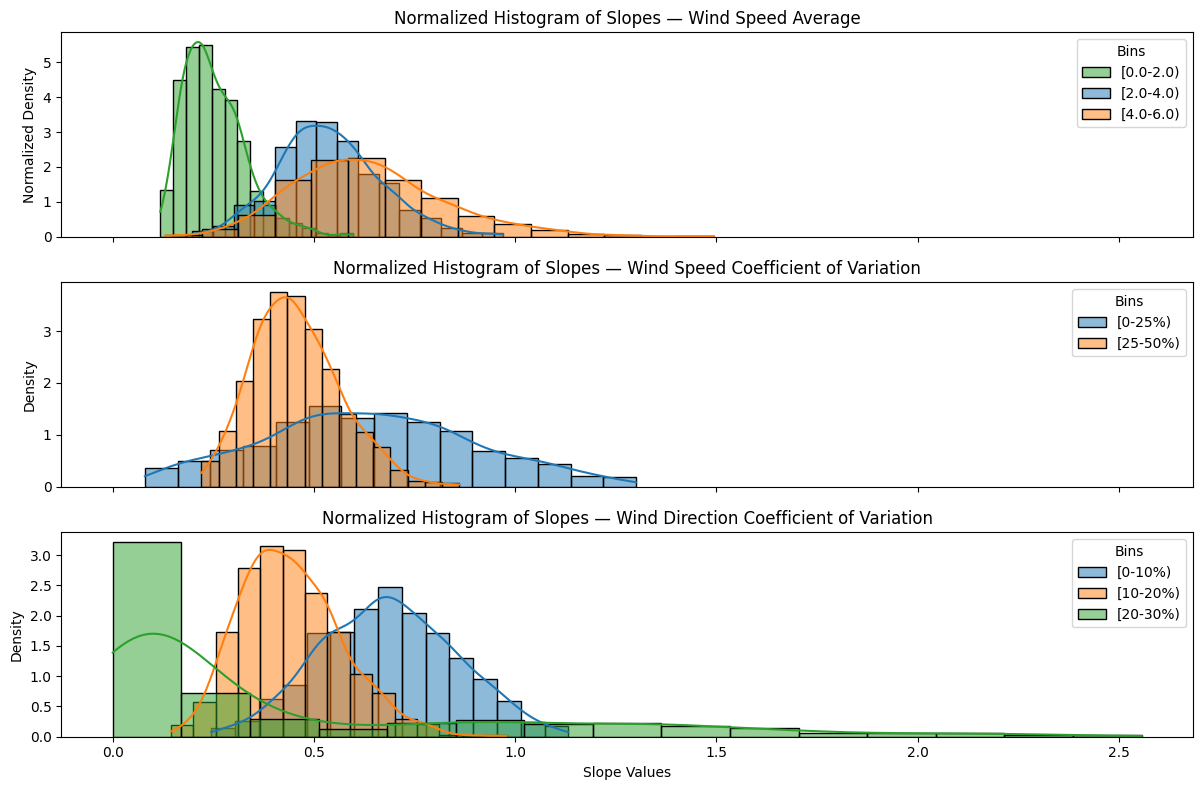

In [8]:
def plot_slope_histograms_subplots(slope_dfs, titles):
    fig, axes = plt.subplots(len(slope_dfs), 1, figsize=(12, 8), sharex=True)
    
    for ax, slope_df, title in zip(axes, slope_dfs, titles):
        for bin in sorted(slope_df.columns):
            slopes = slope_df[bin].dropna()
            sns.histplot(
                slopes,
                label=bin,
                kde=True,
                bins=15,
                stat="density",
                ax=ax,
                color=sns.color_palette("tab10")[list(slope_df.columns).index(bin)]
            )
        ax.set_xlabel('Slope Values')
        ax.set_title(title)
        ax.legend(title='Bins', loc='upper right')
    
    axes[0].set_ylabel('Normalized Density')
    plt.tight_layout()
    plt.savefig('report/plots/wind/wind_bootstrap_analysis/bootstrapped_slope_histograms.png')
    plt.show()

# Call function
plot_slope_histograms_subplots(
    [
        windspeed_avg_slopes,
        windspeed_cov_slopes.drop(columns=['[50-75%)', '[75-100%)']),
        winddir_cov_slopes
    ],
    [
        'Normalized Histogram of Slopes — Wind Speed Average',
        'Normalized Histogram of Slopes — Wind Speed Coefficient of Variation',
        'Normalized Histogram of Slopes — Wind Direction Coefficient of Variation'
    ]
)


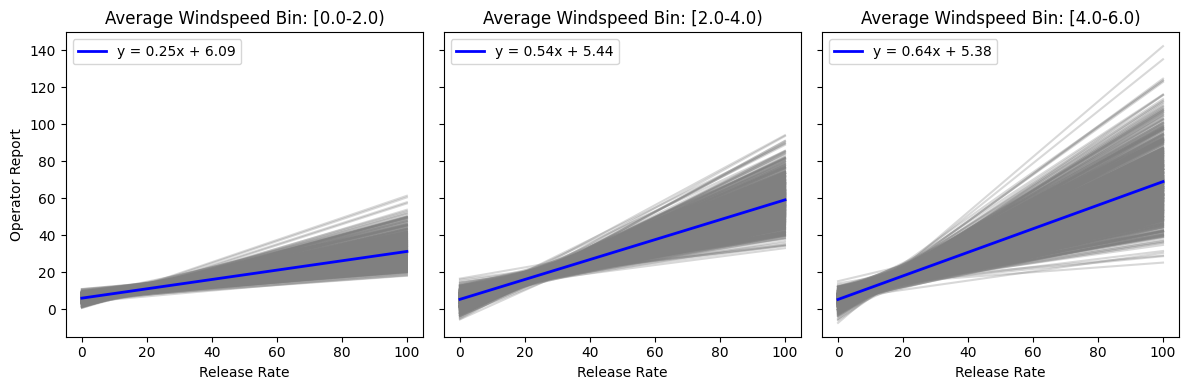

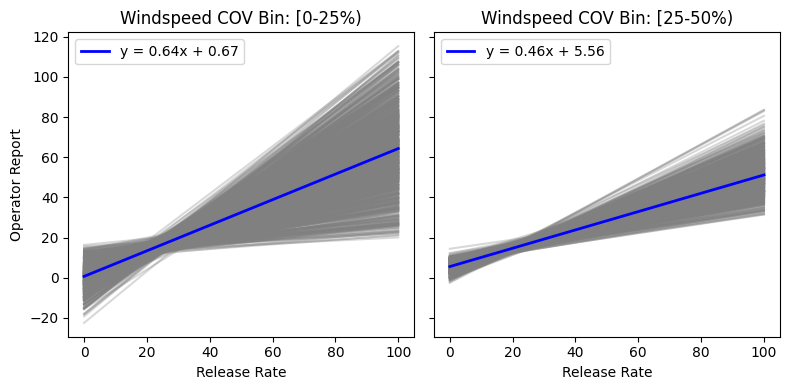

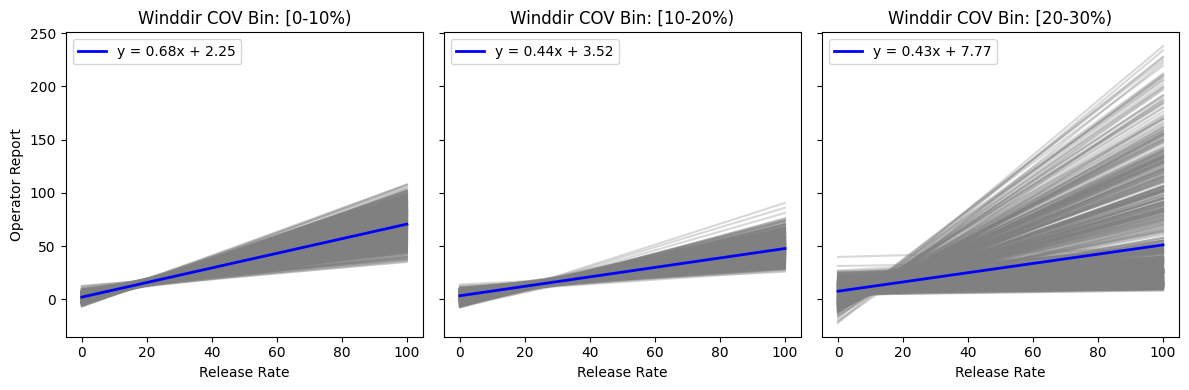

In [9]:
x = np.linspace(0, 100, 100)

def plot_bootstrap_lines(slopes_df, intercepts_df, title_prefix):
    bins = sorted(slopes_df.columns)
    fig, axs = plt.subplots(1, len(bins), figsize=(len(bins)*4, 4), sharey=True)
    
    for i, bin in enumerate(bins):
        ax = axs[i]
        slopes = slopes_df[bin].dropna()
        intercepts = intercepts_df[bin].dropna()

        for m, b in zip(slopes, intercepts):
            ax.plot(x, m * x + b, color='grey', alpha=0.3)

        mean_m = slopes.mean()
        mean_b = intercepts.mean()
        y_avg = mean_m * x + mean_b
        label = f"y = {mean_m:.2f}x + {mean_b:.2f}"
        ax.plot(x, y_avg, color='blue', linewidth=2, label=label)

        ax.set_title(f"{title_prefix} Bin: {bin}")
        ax.set_xlabel("Release Rate")
        if i == 0:
            ax.set_ylabel("Operator Report")
        ax.legend(loc='upper left')
        ax.grid(False)

    plt.tight_layout()
    plt.show()

# Call the function for each slope/intercept pair
plot_bootstrap_lines(windspeed_avg_slopes, windspeed_avg_intercepts, "Average Windspeed")
plot_bootstrap_lines(windspeed_cov_slopes.drop(columns=['[50-75%)', '[75-100%)']), windspeed_cov_intercepts.drop(columns=['[50-75%)', '[75-100%)']), "Windspeed COV")
plot_bootstrap_lines(winddir_cov_slopes, winddir_cov_intercepts, "Winddir COV")

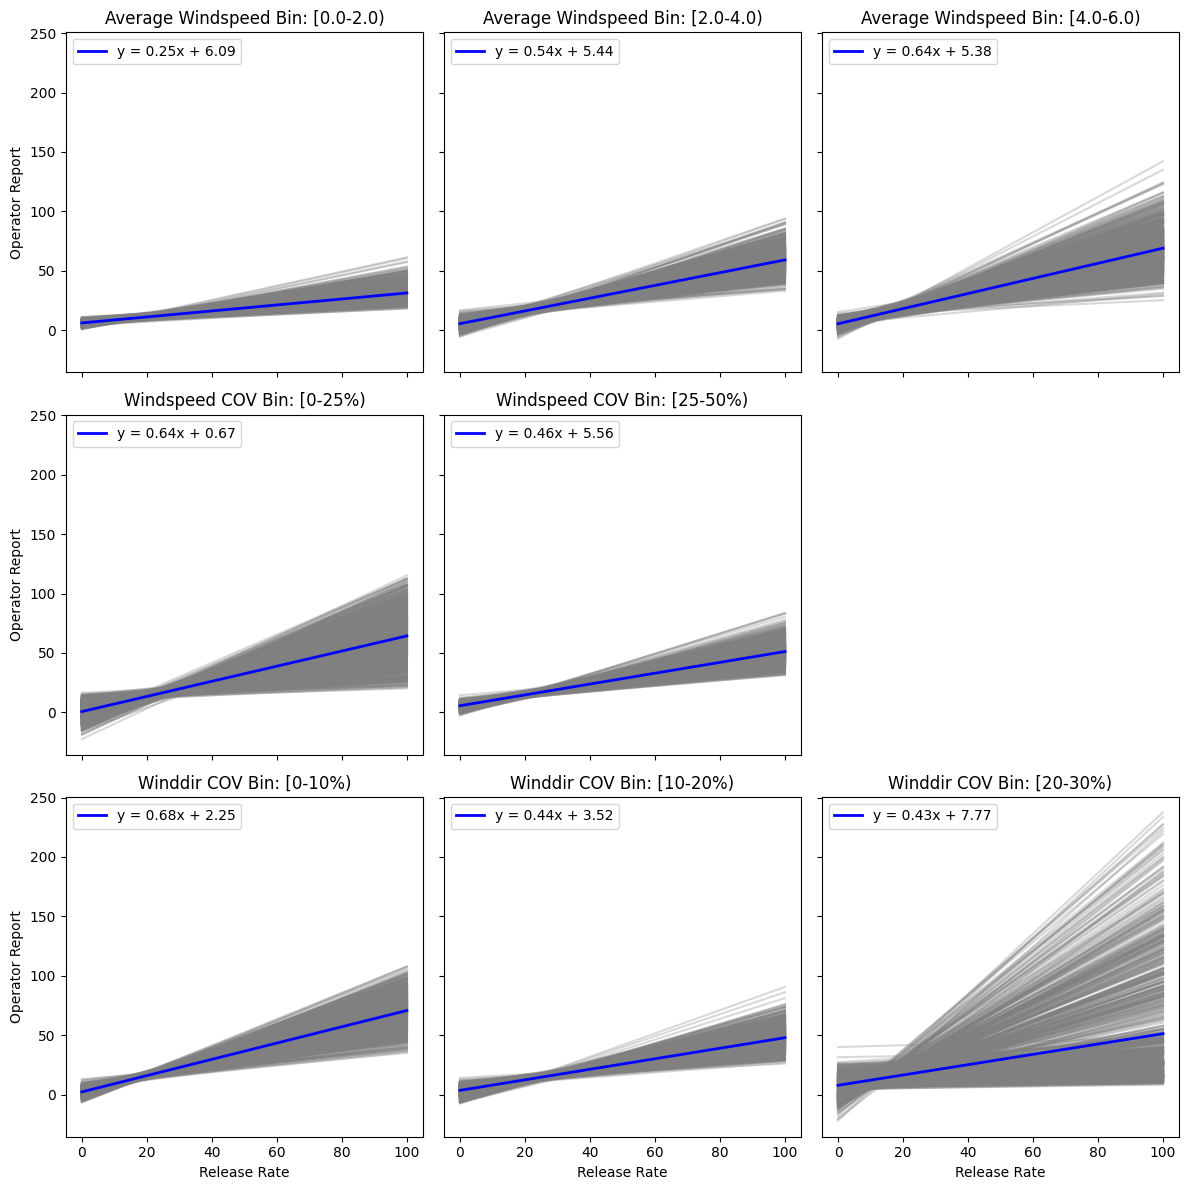

In [10]:
def plot_bootstrap_lines_grid(slopes_list, intercepts_list, titles, x):
    n_rows = len(slopes_list)
    n_cols = max(len(df.columns) for df in slopes_list)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), sharey=True, sharex=True)

    for row in range(n_rows):
        slopes_df = slopes_list[row]
        intercepts_df = intercepts_list[row]
        bins = sorted(slopes_df.columns)
        
        for col in range(n_cols):
            ax = axs[row, col] if n_rows > 1 else axs[col]
            
            if col < len(bins):
                bin = bins[col]
                slopes = slopes_df[bin].dropna()
                intercepts = intercepts_df[bin].dropna()

                for m, b in zip(slopes, intercepts):
                    ax.plot(x, m * x + b, color='grey', alpha=0.3)

                mean_m = slopes.mean()
                mean_b = intercepts.mean()
                y_avg = mean_m * x + mean_b
                label = f"y = {mean_m:.2f}x + {mean_b:.2f}"
                ax.plot(x, y_avg, color='blue', linewidth=2, label=label)

                ax.set_title(f"{titles[row]} Bin: {bin}")
                ax.legend(loc='upper left')
            else:
                ax.axis('off')  # Hide unused subplot

            if col == 0:
                ax.set_ylabel("Operator Report")
            if row == n_rows - 1:
                ax.set_xlabel("Release Rate")
            ax.grid(False)

    plt.tight_layout()
    plt.savefig('report/plots/wind/wind_bootstrap_analysis/bootstrapped_parity_plots_by_bin.png')
    plt.show()

# Call the function
plot_bootstrap_lines_grid(
    slopes_list=[
        windspeed_avg_slopes,
        windspeed_cov_slopes.drop(columns=['[50-75%)', '[75-100%)']),
        winddir_cov_slopes
    ],
    intercepts_list=[
        windspeed_avg_intercepts,
        windspeed_cov_intercepts.drop(columns=['[50-75%)', '[75-100%)']),
        winddir_cov_intercepts
    ],
    titles=[
        "Average Windspeed",
        "Windspeed COV",
        "Winddir COV"
    ],
    x=np.linspace(0, 100, 100)
)


In [22]:
from scipy.stats import ks_2samp
from itertools import combinations

def ci_test_between_bins(slope_df):
    results = []
    bins = slope_df.columns
    for bin1, bin2 in combinations(bins, 2):
        data1 = slope_df[bin1].dropna().to_numpy()
        data2 = slope_df[bin2].dropna().to_numpy()
        diff = data1 - data2
        ci_raw = np.percentile(diff, [2.5, 97.5])
        ci = [round(c, 2) for c in ci_raw]
        zero_in_ci = ci[0] <= 0 <= ci[1]
        results.append({
            'Bin 1': bin1,
            'Bin 2': bin2,
            'CI': ci,
            'Includes Zero': zero_in_ci,
        })
    return pd.DataFrame(results)

# Perform CI tests for each slope DataFrame
ci_results_windspeed_avg = ci_test_between_bins(windspeed_avg_slopes)
ci_results_windspeed_cov = ci_test_between_bins(windspeed_cov_slopes.drop(columns=['[50-75%)', '[75-100%)']))
ci_results_winddir_cov = ci_test_between_bins(winddir_cov_slopes)

# Display the results
print("CI Test Results - Wind Speed Average:")
print(ci_results_windspeed_avg)

print("\nCI Test Results - Wind Speed Coefficient of Variation:")
print(ci_results_windspeed_cov)

print("\nCI Test Results - Wind Direction Coefficient of Variation:")
print(ci_results_winddir_cov)


CI Test Results - Wind Speed Average:
       Bin 1      Bin 2             CI  Includes Zero
0  [2.0-4.0)  [4.0-6.0)  [-0.56, 0.32]           True
1  [2.0-4.0)  [0.0-2.0)   [0.02, 0.58]          False
2  [4.0-6.0)  [0.0-2.0)   [0.03, 0.83]          False

CI Test Results - Wind Speed Coefficient of Variation:
     Bin 1     Bin 2             CI  Includes Zero
0  [0-25%)  [25-50%)  [-0.35, 0.74]           True

CI Test Results - Wind Direction Coefficient of Variation:
      Bin 1     Bin 2             CI  Includes Zero
0   [0-10%)  [10-20%)  [-0.18, 0.63]           True
1   [0-10%)  [20-30%)   [-1.3, 0.91]           True
2  [10-20%)  [20-30%)   [-1.5, 0.63]           True


In [13]:
diff_low_med = windspeed_avg_slopes["[2.0-4.0)"] - windspeed_avg_slopes["[0.0-2.0)"]
ci_low_med = np.percentile(diff_low_med, [2.5, 97.5])


In [15]:
diff_low_med = windspeed_avg_slopes["[4.0-6.0)"] - windspeed_avg_slopes["[2.0-4.0)"]
ci_low_med = np.percentile(diff_low_med, [2.5, 97.5])
print(ci_low_med)


[np.float64(-0.3212266561051922) np.float64(0.5605987308475291)]
